In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from shapely.ops import transform
import warnings
warnings.filterwarnings('ignore')

# Carichiamo entrambe le versioni dei Stadsdeel
stadsdeel_water = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Stadsdeel_geojson_latlng.json")
stadsdeel_nowater = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Stadsdeel_exclwater_geojson_latlng.json")

print(f"Stadsdeel con acqua: {len(stadsdeel_water)}")
print(stadsdeel_water.columns.tolist())
print(f"\nStadsdeel senza acqua: {len(stadsdeel_nowater)}")
print(stadsdeel_nowater.columns.tolist())

Stadsdeel con acqua: 9
['Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']

Stadsdeel senza acqua: 9
['Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']


In [3]:
print("Colonne stadsdeel_water:", stadsdeel_water.columns.tolist())
print("Colonne stadsdeel_nowater:", stadsdeel_nowater.columns.tolist())
print("\nValori Stadsdeel (water):", stadsdeel_water['Stadsdeel'].tolist())
print("Valori Stadsdeel (nowater):", stadsdeel_nowater['Stadsdeel'].tolist())

Colonne stadsdeel_water: ['Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']
Colonne stadsdeel_nowater: ['Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']

Valori Stadsdeel (water): ['Zuidoost', 'Centrum', 'Noord', 'Westpoort', 'West', 'Nieuw-West', 'Zuid', 'Oost', 'Weesp']
Valori Stadsdeel (nowater): ['Zuidoost', 'Centrum', 'Westpoort', 'Weesp', 'Nieuw-West', 'Noord', 'West', 'Oost', 'Zuid']


In [4]:
print(repr(stadsdeel_water.columns.tolist()))
print(repr(stadsdeel_nowater.columns.tolist()))

['Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']
['Stadsdeelcode', 'Stadsdeel', 'Oppervlakte_m2', 'geometry']


In [5]:
# Uniamo i due dataset per confrontare le superfici
confronto = stadsdeel_water[['Stadsdeel', 'Oppervlakte_m2']].merge(
    stadsdeel_nowater[['Stadsdeel', 'Oppervlakte_m2']],
    on='Stadsdeel',
    suffixes=('_totale', '_terra')
)

# Calcoliamo l'acqua per differenza
confronto['Acqua_m2'] = confronto['Oppervlakte_totale'] - confronto['Oppervlakte_terra']
confronto['Acqua_km2'] = confronto['Acqua_m2'] / 1_000_000
confronto['Perc_acqua'] = (confronto['Acqua_m2'] / confronto['Oppervlakte_totale'] * 100).round(1)

print(confronto[['Stadsdeel', 'Acqua_km2', 'Perc_acqua']].sort_values('Perc_acqua', ascending=False))

KeyError: 'Oppervlakte_totale'

In [6]:
print(confronto.columns.tolist())

['Stadsdeel', 'Oppervlakte_m2_totale', 'Oppervlakte_m2_terra']


In [7]:
confronto['Acqua_m2'] = confronto['Oppervlakte_m2_totale'] - confronto['Oppervlakte_m2_terra']
confronto['Acqua_km2'] = confronto['Acqua_m2'] / 1_000_000
confronto['Perc_acqua'] = (confronto['Acqua_m2'] / confronto['Oppervlakte_m2_totale'] * 100).round(1)

print(confronto[['Stadsdeel', 'Acqua_km2', 'Perc_acqua']].sort_values('Perc_acqua', ascending=False))

    Stadsdeel  Acqua_km2  Perc_acqua
7        Oost   9.623223        31.6
2       Noord  19.256211        30.3
3   Westpoort   8.635082        29.9
1     Centrum   0.669639         8.4
4        West   0.535597         5.1
5  Nieuw-West   1.811172         4.8
8       Weesp   1.208651         4.6
6        Zuid   0.659147         3.8
0    Zuidoost   0.656015         3.3


In [8]:
# VERDE — ricarichiamo e aggreghiamo per Stadsdeel
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json", 
                      on_invalid="ignore")
verde_stadsdeel = green.groupby('Stadsdeel')['Oppervlakte_m2'].sum().reset_index()
verde_stadsdeel.columns = ['Stadsdeel', 'Verde_m2']
verde_stadsdeel['Verde_km2'] = verde_stadsdeel['Verde_m2'] / 1_000_000

# TRAFFICO — ricarichiamo parcheggi e aggreghiamo per Stadsdeel
parking = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Parkeerdruk - buurten_geojson_lnglat.json")
parking_avond = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
].copy()
traffico_stadsdeel = parking_avond.groupby('SDC')['Netto_PKD'].mean().reset_index()
traffico_stadsdeel.columns = ['Stadsdeelcode', 'Pressione_media']

# Mappiamo i codici Stadsdeel ai nomi
mapping_codici = stadsdeel_water[['Stadsdeelcode', 'Stadsdeel']].drop_duplicates()
traffico_stadsdeel = traffico_stadsdeel.merge(mapping_codici, on='Stadsdeelcode')

# NO2 — ricarichiamo e dobbiamo fare uno spatial join con gli Stadsdeel
stations = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2 metingen locaties_geojson_latlng.json")
stations['geometry'] = stations['geometry'].apply(lambda g: transform(lambda x, y: (y, x), g))
stations = stations.set_crs("EPSG:4326")

no2 = pd.read_csv(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2_JAREN.csv", sep=';', encoding='latin-1')
no2.columns = [c.replace('ï»¿', '') for c in no2.columns]
no2_geo = stations.merge(no2, left_on='Code', right_on='CodeJ', how='inner')
no2_geo = no2_geo[no2_geo['_2024'] > 0].copy()

# Join spaziale con Stadsdeel
no2_geo_proj = no2_geo.to_crs(stadsdeel_water.crs)
no2_sjoin = gpd.sjoin(no2_geo_proj, stadsdeel_water[['Stadsdeel', 'geometry']], how='left', predicate='within')
no2_stadsdeel = no2_sjoin.groupby('Stadsdeel')['_2024'].mean().reset_index()
no2_stadsdeel.columns = ['Stadsdeel', 'NO2_medio']

print("Verde:")
print(verde_stadsdeel[['Stadsdeel', 'Verde_km2']])
print("\nTraffico:")
print(traffico_stadsdeel[['Stadsdeel', 'Pressione_media']])
print("\nNO2:")
print(no2_stadsdeel)

DataSourceError: C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Parkeerdruk - buurten_geojson_lnglat.json: No such file or directory

In [9]:
import os

cartella = r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN"
for f in os.listdir(cartella):
    if 'park' in f.lower() or 'parkeer' in f.lower():
        print(f)

amsterdam_no2_parking_correlation.png
amsterdam_parking_pressure.png
amsterdam_park_accessibility.png
Parkeerdruk_buurten.json
park_geojson_lnglat.json


In [10]:
parking = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Parkeerdruk_buurten.json")
parking_avond = parking[
    (parking['Dagdeel'] == 'doordeweeks avond') &
    (parking['Netto_PKD'] > 0) &
    (parking['Netto_PKD'] < 500) &
    (parking['Fout'] == 0)
].copy()
traffico_stadsdeel = parking_avond.groupby('SDC')['Netto_PKD'].mean().reset_index()
traffico_stadsdeel.columns = ['Stadsdeelcode', 'Pressione_media']

mapping_codici = stadsdeel_water[['Stadsdeelcode', 'Stadsdeel']].drop_duplicates()
traffico_stadsdeel = traffico_stadsdeel.merge(mapping_codici, on='Stadsdeelcode')

print("Traffico:")
print(traffico_stadsdeel[['Stadsdeel', 'Pressione_media']])

Traffico:
    Stadsdeel  Pressione_media
0     Centrum        72.928571
1   Westpoort        13.750000
2        West        75.705882
3  Nieuw-West        26.125000
4        Zuid        62.600000
5        Oost        33.357143
6       Noord        51.625000
7       Weesp        51.333333
8    Zuidoost        38.250000


In [11]:
stations = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2 metingen locaties_geojson_latlng.json")
stations['geometry'] = stations['geometry'].apply(lambda g: transform(lambda x, y: (y, x), g))
stations = stations.set_crs("EPSG:4326")

no2 = pd.read_csv(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\NO2_JAREN.csv", sep=';', encoding='latin-1')
no2.columns = [c.replace('ï»¿', '') for c in no2.columns]
no2_geo = stations.merge(no2, left_on='Code', right_on='CodeJ', how='inner')
no2_geo = no2_geo[no2_geo['_2024'] > 0].copy()

no2_geo_proj = no2_geo.to_crs(stadsdeel_water.crs)
no2_sjoin = gpd.sjoin(no2_geo_proj, stadsdeel_water[['Stadsdeel', 'geometry']], how='left', predicate='within')
no2_stadsdeel = no2_sjoin.groupby('Stadsdeel')['_2024'].mean().reset_index()
no2_stadsdeel.columns = ['Stadsdeel', 'NO2_medio']

print(no2_stadsdeel)

Empty DataFrame
Columns: [Stadsdeel, NO2_medio]
Index: []


In [12]:
print(f"CRS no2_geo_proj: {no2_geo_proj.crs}")
print(f"CRS stadsdeel_water: {stadsdeel_water.crs}")
print(f"\nBounds no2_geo_proj: {no2_geo_proj.total_bounds}")
print(f"Bounds stadsdeel_water: {stadsdeel_water.total_bounds}")

CRS no2_geo_proj: EPSG:4326
CRS stadsdeel_water: EPSG:4326

Bounds no2_geo_proj: [ 4.5909   52.2112    5.28301  52.519772]
Bounds stadsdeel_water: [52.2779774  4.7287676 52.431066   5.1076957]


In [13]:
stadsdeel_water_fixed = stadsdeel_water.copy()
stadsdeel_water_fixed['geometry'] = stadsdeel_water_fixed['geometry'].apply(
    lambda g: transform(lambda x, y: (y, x), g)
)
stadsdeel_water_fixed = stadsdeel_water_fixed.set_crs("EPSG:4326", allow_override=True)

print(f"Nuovi bounds: {stadsdeel_water_fixed.total_bounds}")

# Rifacciamo il join
no2_sjoin = gpd.sjoin(no2_geo_proj, stadsdeel_water_fixed[['Stadsdeel', 'geometry']], how='left', predicate='within')
no2_stadsdeel = no2_sjoin.groupby('Stadsdeel')['_2024'].mean().reset_index()
no2_stadsdeel.columns = ['Stadsdeel', 'NO2_medio']

print(no2_stadsdeel)

Nuovi bounds: [ 4.7287676 52.2779774  5.1076957 52.431066 ]
    Stadsdeel  NO2_medio
0     Centrum  20.205882
1  Nieuw-West  17.262500
2       Noord  19.566667
3        Oost  18.073077
4       Weesp  14.685714
5        West  20.136667
6        Zuid  20.130769
7    Zuidoost  16.542857


In [14]:
# Uniamo tutto
analisi_finale = confronto[['Stadsdeel', 'Perc_acqua']]\
    .merge(verde_stadsdeel[['Stadsdeel', 'Verde_km2']], on='Stadsdeel', how='inner')\
    .merge(traffico_stadsdeel[['Stadsdeel', 'Pressione_media']], on='Stadsdeel', how='inner')\
    .merge(no2_stadsdeel, on='Stadsdeel', how='inner')

print(analisi_finale)

    Stadsdeel  Perc_acqua  Verde_km2  Pressione_media  NO2_medio
0    Zuidoost         3.3   5.251325        38.250000  16.542857
1     Centrum         8.4   0.082263        72.928571  20.205882
2       Noord        30.3   2.726583        51.625000  19.566667
3        West         5.1   0.557488        75.705882  20.136667
4  Nieuw-West         4.8   5.862203        26.125000  17.262500
5        Zuid         3.8   1.819623        62.600000  20.130769
6        Oost        31.6   1.849505        33.357143  18.073077


In [15]:
# Matrice di correlazione
variabili = analisi_finale[['Perc_acqua', 'Verde_km2', 'Pressione_media', 'NO2_medio']]
corr_matrix = variabili.corr()

print(corr_matrix.round(3))

                 Perc_acqua  Verde_km2  Pressione_media  NO2_medio
Perc_acqua            1.000     -0.174           -0.260      0.044
Verde_km2            -0.174      1.000           -0.829     -0.868
Pressione_media      -0.260     -0.829            1.000      0.882
NO2_medio             0.044     -0.868            0.882      1.000


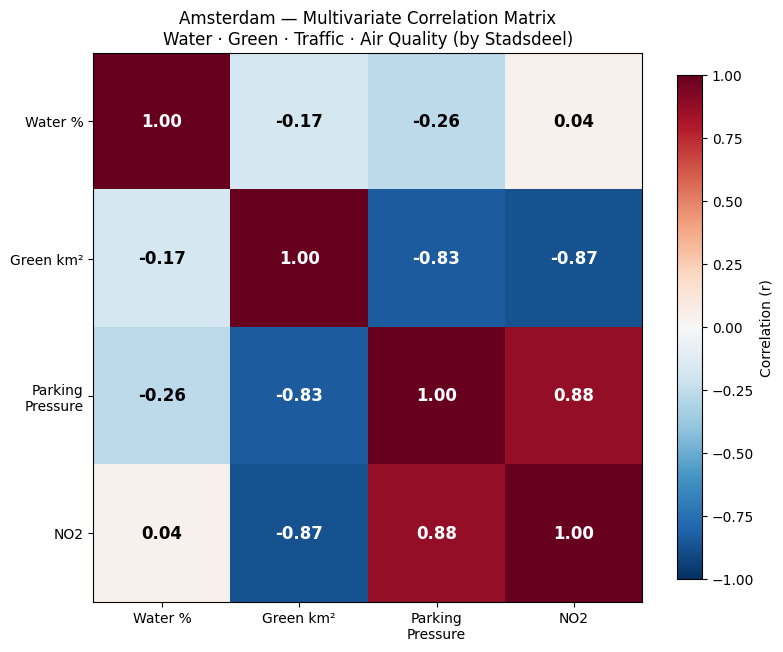

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

# Etichette
labels = ['Water %', 'Green km²', 'Parking\nPressure', 'NO2']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)

# Valori numerici sulle celle
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                color=color, fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlation (r)', shrink=0.8)
ax.set_title('Amsterdam — Multivariate Correlation Matrix\nWater · Green · Traffic · Air Quality (by Stadsdeel)', fontsize=12)

plt.tight_layout()
plt.savefig('amsterdam_multivariate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()